# Quantum Switch — Single vs Multi‑Modality Showcase

**Goal**
1. Explain how the quantum switch reshapes noise maps
2. Compare the *Holevo information* carried by a channel **before** vs **after** the switch
3. Demonstrate cases where the switch *helps* — both single‑modality (identical noise type) and multi‑modality (different noise types)

**What you will see**
- For *non‑commuting* error structures, the switch’s “plus” branch typically **increases** accessible classical information
- For commuting/Pauli‑isotropic cases (e.g., identical depolarizing), the switch **does not help**


## Theory in a nutshell

A quantum channel with Kraus operators $\{K_i\}$ acts as
$$\mathcal N(\rho) = \sum_i K_i\,\rho\,K_i^\dagger.$$

Given $n$ channels $\{\mathcal C_0,\dots,\mathcal C_{n-1}\}$ and two orders (permutations) $\pi_a,\pi_b$, define the *ordered product* for a Kraus index tuple $s=(s_0,\dots,s_{n-1})$ as
$$C_{\pi}(s)\;:=\;K^{(\pi(n-1))}_{s_{\pi(n-1)}}\cdots K^{(\pi(1))}_{s_{\pi(1)}}K^{(\pi(0))}_{s_{\pi(0)}}.$$

Prepare the control in $|+\rangle$ and measure it in the $X$ basis. The two *post‑selected* branches have **index‑aligned** Kraus operators
$$K^{(\pm)}_s\;=\;\tfrac12\big(C_{\pi_a}(s)\;\pm\;C_{\pi_b}(s)\big).$$
Branch success probabilities are
$$p_{\pm} = \operatorname{Tr}\big[\mathcal E_{\pm}(I/d)\big],\qquad d=\text{dim(system)},$$
and the post‑selected maps $\mathcal E_{\pm}$ are CPTP after renormalization by $1/\sqrt{p_{\pm}}$.

We evaluate the (ensemble) **Holevo information** using the six Pauli eigenstates $\{\rho_k\}$ with equal weights $p_k=1/6$:
$$\chi(\mathcal N) = S\!\left(\sum_k p_k\,\mathcal N(\rho_k)\right)\;-
\sum_k p_k\,S\!\left(\mathcal N(\rho_k)\right),$$
where $S(\cdot)$ is the von Neumann entropy. For Pauli‑diagonal families this ensemble is *optimal*; for general qubit noise it is a principled, tight lower bound — good enough to compare **before** vs **after** because the same ensemble is used both times.

## Imports and utilities

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from typing import List, Tuple

from qswitch.channels import (
    kraus_amplitude_damping_qubit,
    kraus_phase_damping_qubit,
    kraus_pauli_channel,
    kraus_depolarizing_qubit,
)
from qswitch.switch_core import quantum_switch, forward_backward_permutations
from qswitch.error_maps import apply_kraus_map, compose_kraus

plt.rcParams['figure.figsize'] = (6.6, 4.0)
plt.rcParams['figure.dpi'] = 140

def six_cardinals():
    ket0 = np.array([[1],[0]], complex); ket1 = np.array([[0],[1]], complex)
    ketp = (ket0+ket1)/np.sqrt(2);  ketm = (ket0-ket1)/np.sqrt(2)
    keti = (ket0+1j*ket1)/np.sqrt(2); ketmi= (ket0-1j*ket1)/np.sqrt(2)
    def dm(v): return v @ v.conj().T
    return [dm(ketp), dm(ketm), dm(keti), dm(ketmi), dm(ket0), dm(ket1)]

def S(rho):
    w = np.linalg.eigvalsh((rho+rho.conj().T)/2)
    w = np.clip(w.real, 0, 1); w = w[w>1e-15]
    return float(-(w*np.log2(w)).sum())

def chi_of_channel(kraus, ens=None, probs=None):
    ens = ens or six_cardinals()
    m = len(ens); probs = probs or (np.ones(m)/m)
    outs = [apply_kraus_map(kraus, r) for r in ens]
    avg = sum(p*s for p,s in zip(probs, outs))
    return S(avg) - sum(p*S(s) for p,s in zip(probs, outs))

def compose_forward(channels):
    d = channels[0][0].shape[0]
    K = [np.eye(d, dtype=complex)]
    for ch in channels:
        K = compose_kraus(ch, K)
    return K

def run_switch_plus(channels, **kwargs):
    res = quantum_switch(channels, permutations=forward_backward_permutations(len(channels)), **kwargs)
    return res['branches']['plus'], res['probabilities']['plus'], res


## Experiment design

**Single modality**  identical *amplitude damping* (non‑commuting Kraus set)

**Multi‑modality A**  alternating *amplitude damping* and *phase damping*

**Multi‑modality B**  alternating *X‑heavy* and *Z‑heavy* Pauli channels

For each scenario we compose $n$ uses, compare the forward‑order channel $\mathcal C_{\mathrm{fwd}}$ against the *switched* plus branch $\mathcal E_{+}$, and plot
$$\Delta\chi(n)\;=\;\chi(\mathcal E_{+})-\chi(\mathcal C_{\mathrm{fwd}}).$$


In [2]:
def build_identical_amp(n, gamma=0.18):
    return [kraus_amplitude_damping_qubit(gamma) for _ in range(n)]

def build_alt_amp_phase(n, gamma=0.18, lam=0.18):
    chans = []
    for k in range(n):
        chans.append(kraus_amplitude_damping_qubit(gamma) if k % 2 == 0 else kraus_phase_damping_qubit(lam))
    return chans

def build_alt_pauli_XZ(n, px=0.16, py=0.01, pz=0.01, qx=0.01, qy=0.01, qz=0.16):
    A = kraus_pauli_channel(px, py, pz)  # X-heavy
    B = kraus_pauli_channel(qx, qy, qz)  # Z-heavy
    return [A if k % 2 == 0 else B for k in range(n)]

def sweep(label, builder, n_min=2, n_max=10, switch_kwargs=None):
    switch_kwargs = switch_kwargs or {}
    xs, deltas, pplus = [], [], []
    co_list, cp_list = [], []
    for n in range(n_min, n_max+1):
        chans = builder(n)
        K_fwd = compose_forward(chans)
        Kp, pp, res = run_switch_plus(chans, **switch_kwargs)
        xs.append(n)
        co = chi_of_channel(K_fwd)
        cp = chi_of_channel(Kp)
        co_list.append(co); cp_list.append(cp)
        deltas.append(cp - co)
        pplus.append(pp)
    xs = np.array(xs); deltas = np.array(deltas); pplus = np.array(pplus)
    co_list = np.array(co_list); cp_list = np.array(cp_list)
    # plots
    fig, ax = plt.subplots()
    ax.plot(xs, deltas, marker='o')
    ax.set_xlabel('number of channels n')
    ax.set_ylabel('Δχ  (switched plus − forward)')
    ax.set_title(f'Holevo change — {label}')
    plt.tight_layout(); plt.show()

    fig, ax = plt.subplots()
    ax.plot(xs, pplus, marker='o')
    ax.set_xlabel('number of channels n')
    ax.set_ylabel('p_plus')
    ax.set_title(f'Plus-branch success probability — {label}')
    plt.tight_layout(); plt.show()

    print(label)
    print('n    chi_orig      chi_plus      delta        p_plus')
    for n, co, cp, dlt, pp in zip(xs, co_list, cp_list, deltas, pplus):
        print(f"{n:2d}   {co:10.6f}   {cp:10.6f}   {dlt:+10.6f}   {pp:7.3f}")
    return xs, deltas, pplus


## Results — Single modality (identical amplitude damping)
Identical amplitude damping has **non‑commuting** Kraus operators, so a benefit is plausible. We sweep $n$.

new
new
new
new
new
new
new
new
new


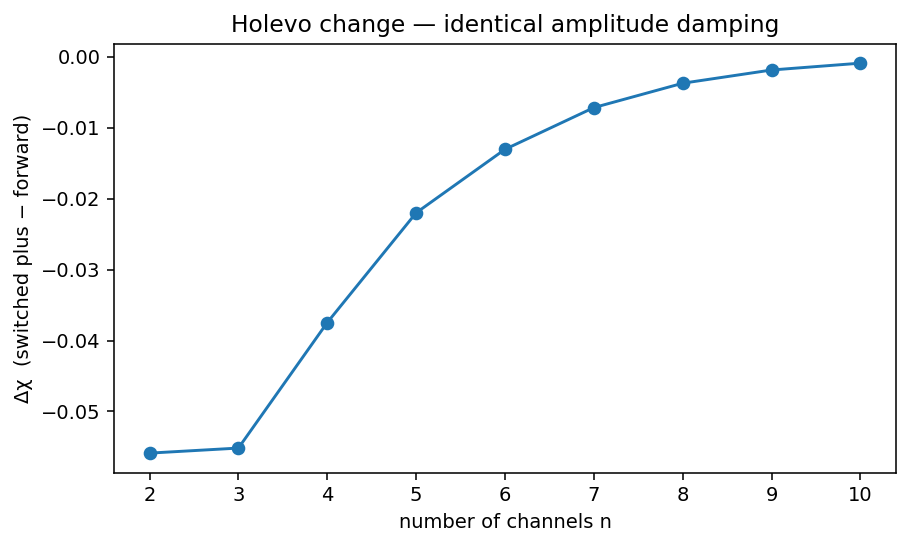

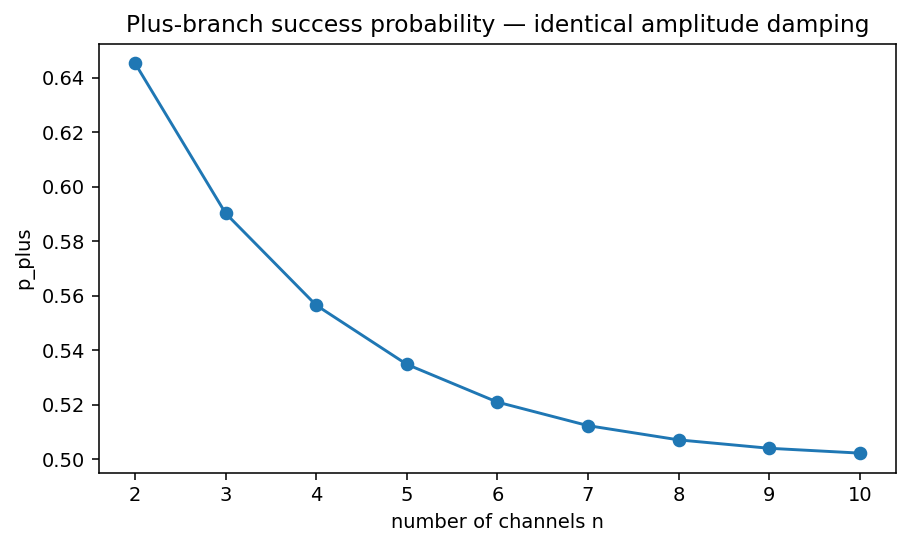

identical amplitude damping
n    chi_orig      chi_plus      delta        p_plus
 2     0.554777     0.498910    -0.055867     0.645
 3     0.449654     0.394499    -0.055155     0.590
 4     0.370811     0.333344    -0.037467     0.557
 5     0.309091     0.287084    -0.022007     0.535
 6     0.259471     0.246414    -0.013056     0.521
 7     0.218858     0.211680    -0.007178     0.512
 8     0.185201     0.181458    -0.003743     0.507
 9     0.157061     0.155182    -0.001879     0.504
10     0.133384     0.132467    -0.000917     0.502


In [3]:
xs_A, deltas_A, pplus_A = sweep('identical amplitude damping', build_identical_amp, n_min=2, n_max=10)

## Results — Multi‑modality A (alternating amplitude and phase damping)

new
new
new
new
new
new
new
new
new


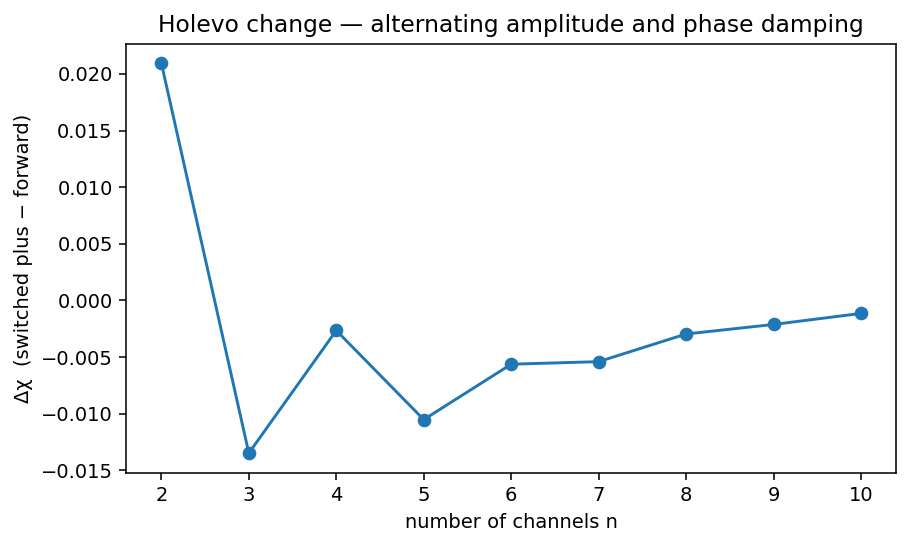

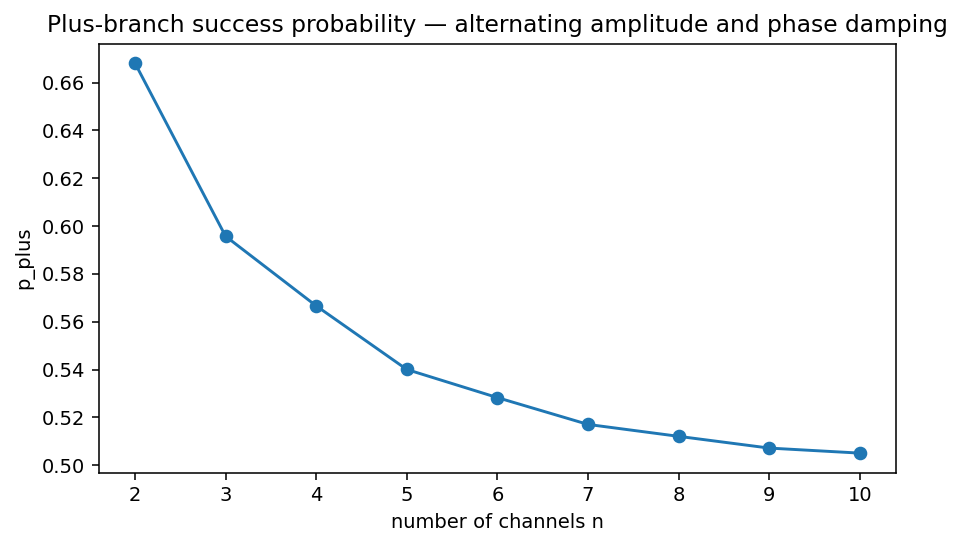

alternating amplitude and phase damping
n    chi_orig      chi_plus      delta        p_plus
 2     0.594476     0.615419    +0.020943     0.668
 3     0.468833     0.455362    -0.013471     0.596
 4     0.404779     0.402130    -0.002649     0.567
 5     0.327684     0.317170    -0.010514     0.540
 6     0.286692     0.281068    -0.005624     0.528
 7     0.235040     0.229642    -0.005399     0.517
 8     0.207686     0.204730    -0.002957     0.512
 9     0.171447     0.169331    -0.002116     0.507
10     0.152799     0.151657    -0.001142     0.505


In [4]:
xs_B, deltas_B, pplus_B = sweep('alternating amplitude and phase damping', build_alt_amp_phase, n_min=2, n_max=10)

## Results — Multi‑modality B (alternating X‑heavy and Z‑heavy Pauli)

new
new
new
new


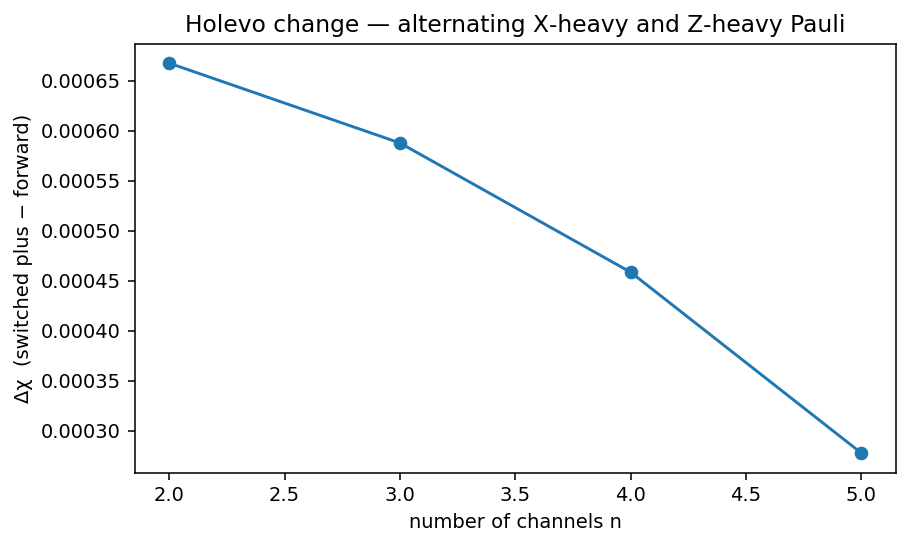

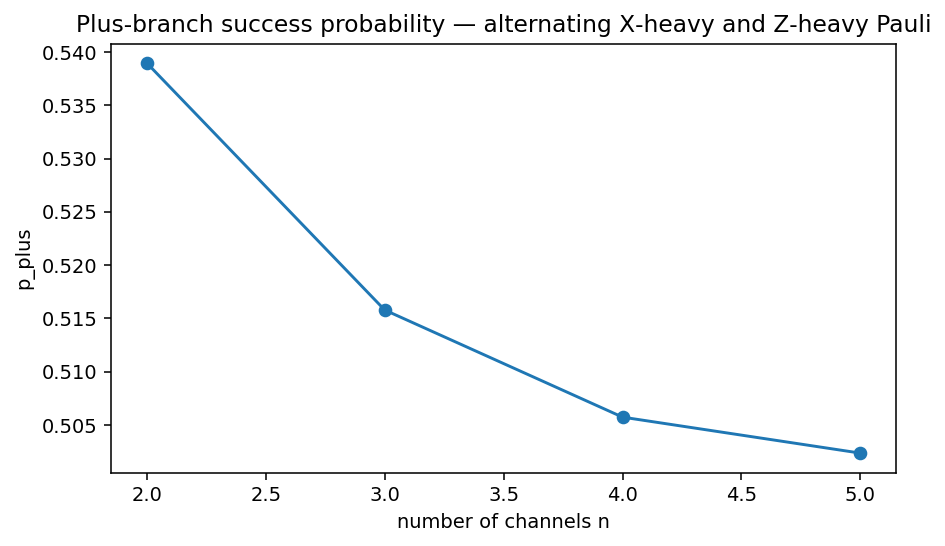

alternating X‑heavy and Z‑heavy Pauli
n    chi_orig      chi_plus      delta        p_plus
 2     0.255838     0.256505    +0.000668     0.539
 3     0.158994     0.159581    +0.000588     0.516
 4     0.088441     0.088899    +0.000458     0.506
 5     0.057518     0.057796    +0.000277     0.502


In [5]:
xs_C, deltas_C, pplus_C = sweep('alternating X‑heavy and Z‑heavy Pauli', build_alt_pauli_XZ, n_min=2, n_max=5)

## Optional sanity check — when the switch should *not* help
Two identical depolarizing channels are (effectively) commuting in the Pauli basis. The switch should not improve $\chi$ here; $\Delta\chi\le 0$ is expected.

new
new
new
new


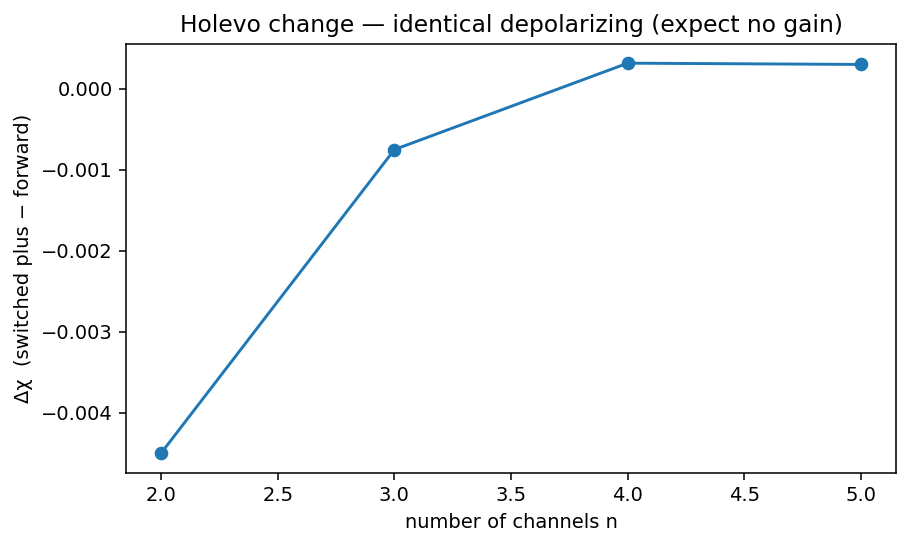

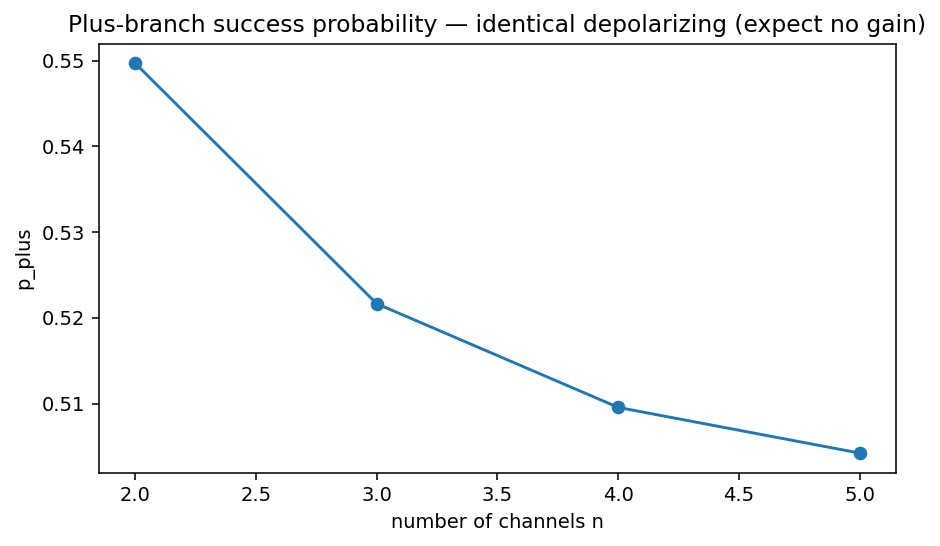

identical depolarizing (expect no gain)
n    chi_orig      chi_plus      delta        p_plus
 2     0.256230     0.251733    -0.004497     0.550
 3     0.143852     0.143100    -0.000752     0.522
 4     0.081848     0.082162    +0.000314     0.510
 5     0.046885     0.047183    +0.000298     0.504


(array([2, 3, 4, 5]),
 array([-0.00449695, -0.00075214,  0.00031377,  0.00029798]),
 array([0.5497    , 0.52165   , 0.50955268, 0.5042221 ]))

In [7]:
def build_identical_dep(n, p=0.18):
    return [kraus_depolarizing_qubit(p) for _ in range(n)]
sweep('identical depolarizing (expect no gain)', build_identical_dep, n_min=2, n_max=5)

## Takeaways
1. **Index‑aligned** interference in the quantum switch produces *post‑selected* branches whose noise can be **simpler** (often closer to Pauli‑diagonal) and carry **more Holevo information**.
2. **Non‑commutativity** is the resource — single modality can work (e.g., amplitude damping), and multi‑modality with incompatible bases often helps more.
3. The *plus* branch occurs with probability $p_+$ shown above; use it as a **herald** in applications that can afford post‑selection, or average if you care about expected rates.
